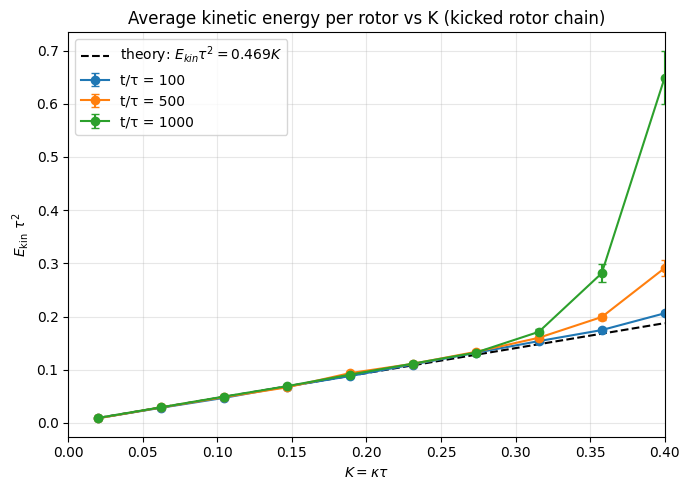

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- parameters ----------
np.random.seed(42)

N = 100                   # number of rotors
nsamples = 40             # number of random initial phase samples
tau = 1.0                 # driving period (set to 1 for simplicity)
K_vals = np.linspace(0.02, 0.4, 10)   # extended to 0.4
nsteps_list = [100, 500, 1000]        # times t/τ

# theoretical prediction: Ekin * tau^2 = 0.469 * K  (for p~ = 0)
def E_theory(K):
    return 0.469 * K

# ---------- time evolution function ----------
def evolve_one(p, phi, kappa, nsteps, tau=1.0):
    # p, phi are arrays length N
    for _ in range(nsteps):
        # kick: includes both neighbors (periodic BC)
        sin_right = np.sin(phi - np.roll(phi, -1))
        sin_left  = np.sin(np.roll(phi, 1) - phi)
        p = p - kappa * sin_right + kappa * sin_left

        # free rotation for time tau
        phi = (phi + tau * p) % (2*np.pi)
    return p, phi

# ---------- main loop ----------
results = {}  # key: nsteps
for nsteps in nsteps_list:
    means = []
    sems = []
    for K in K_vals:
        kappa = K / tau   # here tau=1 so kappa = K
        E_samples = np.zeros(nsamples)
        for s in range(nsamples):
            p0 = np.zeros(N)                               # p_j(0)=0
            phi0 = np.random.uniform(0, 2*np.pi, N)        # random phases
            p_final, phi_final = evolve_one(p0.copy(), phi0.copy(), kappa, nsteps, tau)
            E_samples[s] = np.mean(p_final**2 / 2.0)       # average kinetic energy per rotor
        meanE = E_samples.mean() * (tau**2)               # rescale by tau^2
        semE  = E_samples.std(ddof=1) / np.sqrt(nsamples) * (tau**2)
        means.append(meanE)
        sems.append(semE)
    results[nsteps] = (np.array(means), np.array(sems))

# ---------- plot ----------
plt.figure(figsize=(7,5))
for nsteps in nsteps_list:
    means, sems = results[nsteps]
    plt.errorbar(K_vals, means, yerr=sems, marker='o', linestyle='-', label=f"t/τ = {nsteps}", capsize=3)

# theory line
K_fine = np.linspace(K_vals.min(), K_vals.max(), 300)
plt.plot(K_fine, E_theory(K_fine), 'k--', label="theory: $E_{kin}\\tau^2=0.469K$")

plt.xlabel(r"$K=\kappa\tau$")
plt.ylabel(r"$E_{\mathrm{kin}}\ \tau^{2}$")
plt.title("Average kinetic energy per rotor vs K (kicked rotor chain)")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 0.4)
plt.tight_layout()
plt.show()
